In [ ]:
# Importing the libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Importing the datasets

dataset = pd.read_csv('Position_Salaries.csv')
x = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values


In [101]:
print(x)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]


In [102]:
y = y.reshape(len(y),1)

In [103]:
print(y)

[[  45000]
 [  50000]
 [  60000]
 [  80000]
 [ 110000]
 [ 150000]
 [ 200000]
 [ 300000]
 [ 500000]
 [1000000]]


In [ ]:
# Doing feature scaling on the datasets

from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
sc_y = StandardScaler()
x = sc_x.fit_transform(x)
y = sc_y.fit_transform(y)

In [105]:
print(x)

[[-1.5666989 ]
 [-1.21854359]
 [-0.87038828]
 [-0.52223297]
 [-0.17407766]
 [ 0.17407766]
 [ 0.52223297]
 [ 0.87038828]
 [ 1.21854359]
 [ 1.5666989 ]]


In [106]:
print(y)

[[-0.72004253]
 [-0.70243757]
 [-0.66722767]
 [-0.59680786]
 [-0.49117815]
 [-0.35033854]
 [-0.17428902]
 [ 0.17781001]
 [ 0.88200808]
 [ 2.64250325]]


In [ ]:
# Training the SVM model

from sklearn.svm import SVR
regressor = SVR( kernel= 'rbf')
regressor.fit(x,y)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [108]:
# Doing Inverse of scaling so that get the actual value not the scaled one

sc_y.inverse_transform(regressor.predict(sc_x.transform([[6.5]])).reshape(-1,1))

array([[0.01158103]])

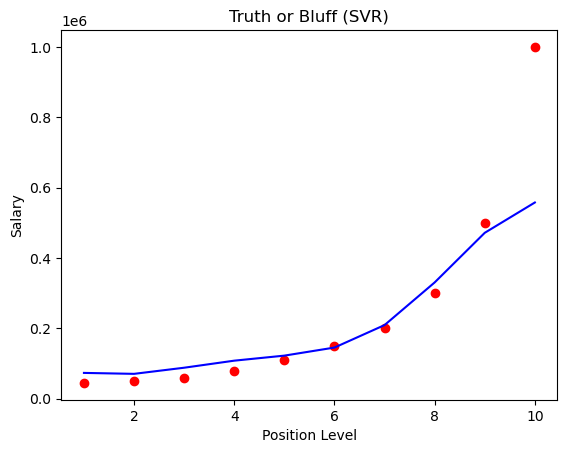

In [109]:
# Visualsing the SVR model results

y_pred = regressor.predict(x)
y_pred = y_pred.reshape(-1,1)

plt.scatter(sc_x.inverse_transform(x), sc_y.inverse_transform(y), color='red')

plt.plot(sc_x.inverse_transform(x),
         sc_y.inverse_transform(y_pred),
         color='blue')

plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

C:\Users\abhii\AppData\Local\Temp\ipykernel_16000\4188147980.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_grid = np.arange(min(x), max(x), 0.1)


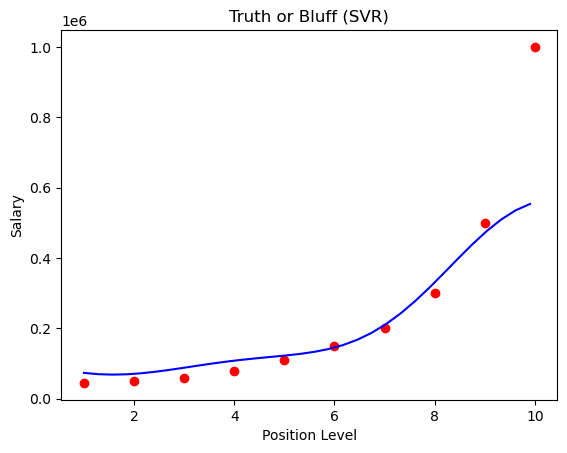

In [110]:
# Visualising the SVR model results in higher resolutions 

x_grid = np.arange(min(x), max(x), 0.1)
x_grid = x_grid.reshape(-1,1)

plt.scatter(sc_x.inverse_transform(x), sc_y.inverse_transform(y), color='red')

plt.plot(sc_x.inverse_transform(x_grid),
         sc_y.inverse_transform(regressor.predict(x_grid).reshape(-1,1)),
         color='blue')

plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()